In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tensorflow import keras

In [2]:
data= pd.read_csv("indian_roads_dataset.csv")

In [3]:
data

,accident_id,city,state,latitude,longitude,date,time,hour,day_of_week,is_weekend,...,visibility,temperature,traffic_density,cause,accident_severity,vehicles_involved,casualties,is_peak_hour,festival,risk_score
0,0,Pune,Maharashtra,18.680827,73.930388,2023-10-22,5:00,5,Sunday,1,...,low,32,high,weather,fatal,2,2,0,NaN,0.85
1,1,Mumbai,Maharashtra,18.817732,72.790846,2023-05-21,4:00,4,Sunday,1,...,high,34,low,weather,major,4,3,0,NaN,0.10
2,2,Mumbai,Maharashtra,19.096889,72.819424,2024-07-10,13:00,13,Wednesday,0,...,low,21,medium,weather,minor,1,1,0,NaN,0.45
3,3,Chandigarh,Punjab,30.787805,76.847507,2025-03-30,11:00,11,Sunday,1,...,low,30,high,distraction,minor,5,2,0,NaN,0.65
4,4,Chennai,Tamil Nadu,12.965155,80.283313,2024-01-25,16:00,16,Thursday,0,...,high,24,low,distraction,minor,2,1,0,NaN,0.10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19995,19995,Bangalore,Karnataka,13.092276,77.599571,2022-09-29,3:00,3,Thursday,0,...,high,31,low,distraction,minor,3,2,0,NaN,0.10
19996,19996,Chennai,Tamil Nadu,13.172928,80.157062,2023-11-25,1:00,1,Saturday,1,...,high,20,low,distraction,major,4,2,0,NaN,0.10
19997,19997,Chennai,Tamil Nadu,12.997170,80.150724,2022-06-18,15:00,15,Saturday,1,...,high,22,low,weather,minor,3,3,0,NaN,0.10
19998,19998,Kolkata,West Bengal,22.454882,88.322213,2023-03-12,4:00,4,Sunday,1,...,high,33,low,poor road,minor,1,0,0,NaN,0.10


In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 24 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   accident_id        20000 non-null  int64  
 1   city               20000 non-null  object 
 2   state              20000 non-null  object 
 3   latitude           20000 non-null  float64
 4   longitude          20000 non-null  float64
 5   date               20000 non-null  object 
 6   time               20000 non-null  object 
 7   hour               20000 non-null  int64  
 8   day_of_week        20000 non-null  object 
 9   is_weekend         20000 non-null  int64  
 10  road_type          20000 non-null  object 
 11  lanes              20000 non-null  int64  
 12  traffic_signal     20000 non-null  int64  
 13  weather            20000 non-null  object 
 14  visibility         20000 non-null  object 
 15  temperature        20000 non-null  int64  
 16  traffic_density    200

In [5]:
data.isnull().sum()

accident_id              0
city                     0
state                    0
latitude                 0
longitude                0
date                     0
time                     0
hour                     0
day_of_week              0
is_weekend               0
road_type                0
lanes                    0
traffic_signal           0
weather                  0
visibility               0
temperature              0
traffic_density          0
cause                    0
accident_severity        0
vehicles_involved        0
casualties               0
is_peak_hour             0
festival             19885
risk_score               0
dtype: int64

In [6]:
data.drop(columns=["festival"], inplace=True)

In [7]:
data.isnull().sum()

accident_id          0
city                 0
state                0
latitude             0
longitude            0
date                 0
time                 0
hour                 0
day_of_week          0
is_weekend           0
road_type            0
lanes                0
traffic_signal       0
weather              0
visibility           0
temperature          0
traffic_density      0
cause                0
accident_severity    0
vehicles_involved    0
casualties           0
is_peak_hour         0
risk_score           0
dtype: int64

In [8]:
data["visibility"].value_counts()

visibility
low       9987
high      6690
medium    3323
Name: count, dtype: int64

In [9]:
data["cause"].value_counts()

cause
distraction      4026
overspeeding     4025
weather          3997
drunk driving    3978
poor road        3974
Name: count, dtype: int64

In [10]:
data["accident_severity"].value_counts()

accident_severity
minor    11025
major     5988
fatal     2987
Name: count, dtype: int64

In [11]:
data.drop(columns=["state", "time", "day_of_week"], inplace=True)

In [12]:
data.head()

,accident_id,city,latitude,longitude,date,hour,is_weekend,road_type,lanes,traffic_signal,weather,visibility,temperature,traffic_density,cause,accident_severity,vehicles_involved,casualties,is_peak_hour,risk_score
0,0,Pune,18.680827,73.930388,2023-10-22,5,1,highway,3,1,fog,low,32,high,weather,fatal,2,2,0,0.85
1,1,Mumbai,18.817732,72.790846,2023-05-21,4,1,urban,4,0,clear,high,34,low,weather,major,4,3,0,0.10
2,2,Mumbai,19.096889,72.819424,2024-07-10,13,0,urban,3,0,fog,low,21,medium,weather,minor,1,1,0,0.45
3,3,Chandigarh,30.787805,76.847507,2025-03-30,11,1,urban,1,1,fog,low,30,high,distraction,minor,5,2,0,0.65
4,4,Chennai,12.965155,80.283313,2024-01-25,16,0,highway,3,1,clear,high,24,low,distraction,minor,2,1,0,0.10


In [13]:
data.drop(columns=["accident_id"], inplace=True)

In [14]:
from sklearn.preprocessing import OneHotEncoder

In [15]:
onehot= OneHotEncoder(handle_unknown="ignore", sparse_output=False)

In [16]:
data["date"]= pd.to_datetime(data["date"])

In [17]:
data["year"]= data["date"].dt.year
data["month"]= data["date"].dt.month
data["day"]= data["date"].dt.day

In [18]:
data.drop("date", axis=1, inplace=True)

In [19]:
data.duplicated().sum()

np.int64(0)

In [20]:
city= onehot.fit_transform(data[["city"]])

In [21]:
city= pd.DataFrame(city, columns=onehot.get_feature_names_out(["city"]), index=data.index)

In [22]:
data= pd.concat([data, city], axis=1)

In [23]:
data.drop(columns=["city"], inplace=True)

In [24]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 28 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   latitude           20000 non-null  float64
 1   longitude          20000 non-null  float64
 2   hour               20000 non-null  int64  
 3   is_weekend         20000 non-null  int64  
 4   road_type          20000 non-null  object 
 5   lanes              20000 non-null  int64  
 6   traffic_signal     20000 non-null  int64  
 7   weather            20000 non-null  object 
 8   visibility         20000 non-null  object 
 9   temperature        20000 non-null  int64  
 10  traffic_density    20000 non-null  object 
 11  cause              20000 non-null  object 
 12  accident_severity  20000 non-null  object 
 13  vehicles_involved  20000 non-null  int64  
 14  casualties         20000 non-null  int64  
 15  is_peak_hour       20000 non-null  int64  
 16  risk_score         200

In [25]:
road_type= onehot.fit_transform(data[["road_type"]])

In [26]:
road_type= pd.DataFrame(road_type, columns=onehot.get_feature_names_out(["road_type"]), index=data.index)

In [27]:
data= pd.concat([data, road_type], axis=1)

In [28]:
data.drop(columns=["road_type"], inplace=True)

In [29]:
weather= onehot.fit_transform(data[["weather"]])

In [30]:
weather= pd.DataFrame(weather, columns= onehot.get_feature_names_out(["weather"]), index=data.index)

In [31]:
data= pd.concat([data, weather], axis=1)

In [32]:
data

,latitude,longitude,hour,is_weekend,lanes,traffic_signal,weather,visibility,temperature,traffic_density,...,city_Hyderabad,city_Kolkata,city_Mumbai,city_Pune,road_type_highway,road_type_rural,road_type_urban,weather_clear,weather_fog,weather_rain
0,18.680827,73.930388,5,1,3,1,fog,low,32,high,...,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0
1,18.817732,72.790846,4,1,4,0,clear,high,34,low,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0
2,19.096889,72.819424,13,0,3,0,fog,low,21,medium,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
3,30.787805,76.847507,11,1,1,1,fog,low,30,high,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
4,12.965155,80.283313,16,0,3,1,clear,high,24,low,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19995,13.092276,77.599571,3,0,1,1,clear,high,31,low,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0
19996,13.172928,80.157062,1,1,1,1,clear,high,20,low,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0
19997,12.997170,80.150724,15,1,3,0,clear,high,22,low,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0
19998,22.454882,88.322213,4,1,3,1,clear,high,33,low,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0


In [33]:
visibility= onehot.fit_transform(data[["visibility"]])

In [34]:
visibility= pd.DataFrame(visibility, columns= onehot.get_feature_names_out(["visibility"]), index=data.index)

In [35]:
data= pd.concat([data, visibility], axis=1)

In [36]:
traffic_den= onehot.fit_transform(data[["traffic_density"]])

In [37]:
traffic_den= pd.DataFrame(traffic_den, columns=onehot.get_feature_names_out(["traffic_density"]),index=data.index)

In [38]:
data= pd.concat([data, traffic_den], axis=1)

In [39]:
data.drop(columns=["weather", "visibility", "traffic_density"], inplace=True)

In [40]:
cause= onehot.fit_transform(data[["cause"]])

In [41]:
cause= pd.DataFrame(cause, columns=onehot.get_feature_names_out(["cause"]), index=data.index)

In [42]:
data= pd.concat([data, cause], axis=1)

In [43]:
data

,latitude,longitude,hour,is_weekend,lanes,traffic_signal,temperature,cause,accident_severity,vehicles_involved,...,visibility_low,visibility_medium,traffic_density_high,traffic_density_low,traffic_density_medium,cause_distraction,cause_drunk driving,cause_overspeeding,cause_poor road,cause_weather
0,18.680827,73.930388,5,1,3,1,32,weather,fatal,2,...,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1,18.817732,72.790846,4,1,4,0,34,weather,major,4,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
2,19.096889,72.819424,13,0,3,0,21,weather,minor,1,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
3,30.787805,76.847507,11,1,1,1,30,distraction,minor,5,...,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
4,12.965155,80.283313,16,0,3,1,24,distraction,minor,2,...,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19995,13.092276,77.599571,3,0,1,1,31,distraction,minor,3,...,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0
19996,13.172928,80.157062,1,1,1,1,20,distraction,major,4,...,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0
19997,12.997170,80.150724,15,1,3,0,22,weather,minor,3,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
19998,22.454882,88.322213,4,1,3,1,33,poor road,minor,1,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0


In [44]:
accident_sev= onehot.fit_transform(data[["accident_severity"]])

In [45]:
accident_sev= pd.DataFrame(accident_sev, columns=onehot.get_feature_names_out(["accident_severity"]), index=data.index)

In [46]:
data= pd.concat([data, accident_sev], axis=1)

In [47]:
data.drop(columns=["cause", "accident_severity"], inplace=True)

In [48]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 42 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   latitude                 20000 non-null  float64
 1   longitude                20000 non-null  float64
 2   hour                     20000 non-null  int64  
 3   is_weekend               20000 non-null  int64  
 4   lanes                    20000 non-null  int64  
 5   traffic_signal           20000 non-null  int64  
 6   temperature              20000 non-null  int64  
 7   vehicles_involved        20000 non-null  int64  
 8   casualties               20000 non-null  int64  
 9   is_peak_hour             20000 non-null  int64  
 10  risk_score               20000 non-null  float64
 11  year                     20000 non-null  int32  
 12  month                    20000 non-null  int32  
 13  day                      20000 non-null  int32  
 14  city_Bangalore        

In [49]:
data["risk_score"].value_counts()

risk_score
0.45    6421
0.10    3149
0.65    2740
0.25    2111
0.30    1664
0.80    1508
0.60    1304
0.85     298
0.40     269
1.00     227
0.50     212
0.55      41
0.75      19
0.20      12
0.90      11
0.35       7
0.70       6
0.95       1
Name: count, dtype: int64

In [50]:
from keras.layers import Dense, Input, Flatten

In [51]:
from keras.models import Sequential

In [52]:
x= data.drop(columns=["risk_score"])

In [53]:
y= data["risk_score"].copy()

In [54]:
from sklearn.model_selection import train_test_split

In [55]:
x_train, x_test, y_train, y_test= train_test_split(x,y,test_size=0.2,random_state=42)

In [56]:
x_train.shape

(16000, 41)

In [57]:
x_test.shape

(4000, 41)

In [58]:
model= Sequential([
    Input(shape=(41,)),
    Dense(32, activation="relu"),
    Dense(16, activation="relu"),
    Dense(8, activation="relu"),
    Dense(4, activation="relu"),
    Dense(2, activation="relu"),
    Dense(1, activation="linear")
])

In [59]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32)             │         1,344 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 4)              │            36 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 2)              │            10 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │             3 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,057 (8.04 KB)

 Trainable params: 2,057 (8.04 KB)

 Non-trainable params: 0 (0.00 B)

In [60]:
model.compile(
    optimizer="Adam",
    loss="mean_squared_error",
    metrics=["accuracy"]
)

In [61]:
from keras.callbacks import EarlyStopping
callback= EarlyStopping(
    monitor="val_loss",
    min_delta=0.0001,
    patience=10,
    mode="auto",
    baseline=None,
    restore_best_weights=True,
    verbose=1
)

In [62]:
from sklearn.preprocessing import StandardScaler
scaler= StandardScaler()

In [63]:
x_train_scaled= scaler.fit_transform(x_train)
x_test_scaled= scaler.transform(x_test)

In [64]:
history= model.fit(x_train_scaled, y_train, epochs=100, validation_split=0.2, callbacks=callback)

Epoch 1/100
400/400 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.0103 - loss: 0.0148 - val_accuracy: 0.0125 - val_loss: 0.0037
Epoch 2/100
400/400 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.0112 - loss: 0.0022 - val_accuracy: 0.0125 - val_loss: 0.0015
Epoch 3/100
400/400 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.0112 - loss: 0.0010 - val_accuracy: 0.0125 - val_loss: 8.5938e-04
Epoch 4/100
400/400 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.0112 - loss: 6.3064e-04 - val_accuracy: 0.0125 - val_loss: 5.9930e-04
Epoch 5/100
400/400 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.0112 - loss: 4.4124e-04 - val_accuracy: 0.0125 - val_loss: 4.2190e-04
Epoch 6/100
400/400 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.0112 - loss: 3.3612e-04 - val_accuracy: 0.0125 - val_loss: 3.2628e-04
Epoch 7/100
400/400 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.0112 - loss: 2.6563e-04 - val_accuracy: 0.0125 - val_loss: 2.6079e-04
Epoch 8/100
400/400 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accura

In [65]:
import matplotlib.pyplot as plt

In [66]:
from sklearn.metrics import r2_score

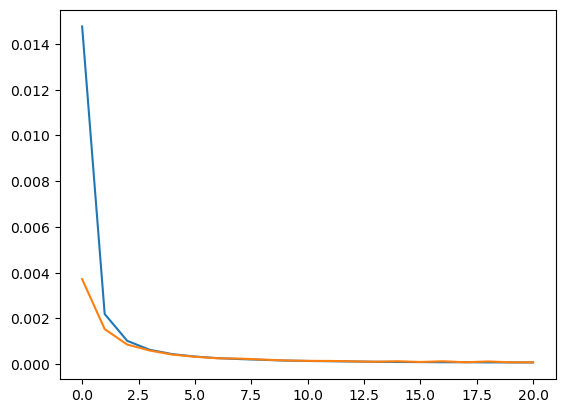

In [67]:
plt.plot(history.history["loss"])
plt.plot(history.history["val_loss"])

In [68]:
y_pred= model.predict(x_test_scaled)

125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 538us/step


In [69]:
r2_score(y_test, y_pred)

0.9965628969528872

In [70]:
y_pred

array([[0.10106656],
       [0.30911928],
       [0.6465057 ],
       ...,
       [0.25473768],
       [0.6416097 ],
       [0.2416211 ]], dtype=float32)

In [75]:
data["ewma"]= data["risk_score"].ewm(span=19, adjust=False).mean()

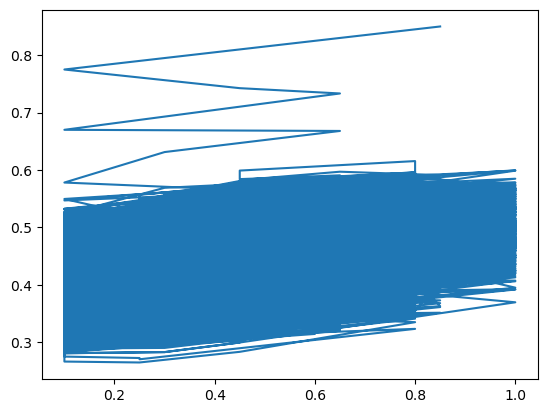

In [76]:
plt.plot(data["risk_score"], data["ewma"], label= "ewma")